# Compare two finite-temperature conductance simulations

This notebook loads the two `.npz` datasets, copies the main quantities into simple NumPy arrays, checks that the magnetic-field grids coincide, and plots

\[
\Delta G(B) = G_1(B)-G_0(B).
\]

The conductances stored in `G_2terminal` are in units of \(e^2/h\).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Input files
# ============================================================

file_0 = "0two_terminal_transport_results_finite_T.npz"
file_1 = "1two_terminal_transport_results_finite_T.npz"

data_0 = np.load(file_0, allow_pickle=True)
data_1 = np.load(file_1, allow_pickle=True)

print("Dataset 0 keys:")
print(data_0.files)

print("\nDataset 1 keys:")
print(data_1.files)

Dataset 0 keys:
['B', 'mu', 'indices', 'kBT_meV', 'temperature_K', 'temperature_mode', 'T_over_hbar_omega_c', 'window_kBT', 'n_energy_points', 'G_T0', 'G_2terminal', 'R_2terminal', 'G10', 'energy_grids_meV', 'G_energy_e2h', 'T_mu_stack', 'T_stack']

Dataset 1 keys:
['B', 'mu', 'indices', 'kBT_meV', 'temperature_K', 'temperature_mode', 'T_over_hbar_omega_c', 'window_kBT', 'n_energy_points', 'G_T0', 'G_2terminal', 'R_2terminal', 'G10', 'energy_grids_meV', 'G_energy_e2h', 'T_mu_stack', 'T_stack']


In [3]:
# ============================================================
# Store the relevant quantities in simple NumPy arrays
# ============================================================

# Dataset 0
B_0  = np.array(data_0["B"])
mu_0 = np.array(data_0["mu"])
G_0  = np.array(data_0["G_2terminal"])
R_0  = np.array(data_0["R_2terminal"])

# Dataset 1
B_1  = np.array(data_1["B"])
mu_1 = np.array(data_1["mu"])
G_1  = np.array(data_1["G_2terminal"])
R_1  = np.array(data_1["R_2terminal"])

print("Number of B points:")
print("dataset 0:", len(B_0))
print("dataset 1:", len(B_1))

Number of B points:
dataset 0: 300
dataset 1: 300


In [4]:
# ============================================================
# Check that the two simulations use the same B grid
# ============================================================

same_B_grid = np.allclose(B_0, B_1)

print("Same B grid:", same_B_grid)

if not same_B_grid:
    raise ValueError(
        "The two datasets have different B grids. "
        "Interpolation is required before subtracting the conductances."
    )

# Since the grids coincide, use a single B array from now on
B = B_0.copy()

Same B grid: True


In [5]:
from scipy.ndimage import gaussian_filter

G_0_smooth = gaussian_filter(G_0, sigma=1)
G_1_smooth = gaussian_filter(G_1, sigma=1)

# ============================================================
# Conductance difference
# ============================================================

# Difference: dataset 1 minus dataset 0
Delta_G = G_1_smooth - G_0_smooth + 1
rhoxxnu = (1-Delta_G)/Delta_G

In [6]:

# ============================================================
# Find centers of integer conductance plateaus
# ============================================================

G = np.asarray(G_0_smooth)
B = np.asarray(B_0)

# Tolerance for considering G "integer"
tol = 0.05

plateau_centers = []

# Integers covered by the conductance range
n_min = max(1, int(np.ceil(np.min(G))))
n_max = int(np.floor(np.max(G)))

for n in range(n_min, n_max + 1):

    # Points sufficiently close to integer n
    mask = np.abs(G - n) < tol
    indices = np.where(mask)[0]

    if len(indices) == 0:
        continue

    # Split into contiguous regions
    regions = np.split(
        indices,
        np.where(np.diff(indices) > 1)[0] + 1
    )

    # If there are multiple regions, keep the widest one
    region = max(regions, key=len)

    # Center of plateau in B
    B_left  = B[region[0]]
    B_right = B[region[-1]]
    B_center = 0.5 * (B_left + B_right)

    # Index closest to the plateau center
    idx_center = region[np.argmin(np.abs(B[region] - B_center))]

    plateau_centers.append((n, idx_center, B[idx_center]))


# Print results
print("Plateau   index       B")
print("--------------------------")
for n, idx, Bc in plateau_centers:
    print(f"{n:4d}     {idx:5d}     {Bc:.6f}")


# Convenient arrays
plateau_n   = np.array([p[0] for p in plateau_centers])
plateau_idx = np.array([p[1] for p in plateau_centers])
plateau_B   = np.array([p[2] for p in plateau_centers])

Plateau   index       B
--------------------------
   2       283     3.676768
   3       225     2.505051
   4       192     1.896790
   5       159     1.515808
   6       133     1.266385
   7       110     1.083023
   8        90     0.952026
   9        69     0.842962
  10        46     0.756987


In [7]:
# ============================================================
# Electrostatic potential datasets for the new top panel
# ============================================================

pot_file_0 = "0data.npz"       # S-QPC / close top gate
pot_file_1 = "1data.npz"    # bare / effectively distant top gate

pot_data_0 = np.load(pot_file_0, allow_pickle=True)
pot_data_1 = np.load(pot_file_1, allow_pickle=True)

# Coordinates and self-consistent potentials
x_pot_0 = np.array(pot_data_0["x"])
y_pot_0 = np.array(pot_data_0["y"])
U_pot_0 = np.array(pot_data_0["U"])

x_pot_1 = np.array(pot_data_1["x"])
y_pot_1 = np.array(pot_data_1["y"])
U_pot_1 = np.array(pot_data_1["U"])

# Crop the numerical x coordinate to x = +/- 500 nm.
# IMPORTANT: numerical coordinates/data are not transposed.
# Only the displayed axis labels are swapped in the figure below.
crop_0 = (x_pot_0 >= -500.0) & (x_pot_0 <= 500.0)
crop_1 = (x_pot_1 >= -500.0) & (x_pot_1 <= 500.0)

x_pot_0_crop = x_pot_0[crop_0]
x_pot_1_crop = x_pot_1[crop_1]
U_pot_0_crop = U_pot_0[:, crop_0]
U_pot_1_crop = U_pot_1[:, crop_1]

# Common color scale for the two potential maps
vmin_U = min(np.nanmin(U_pot_0_crop), np.nanmin(U_pot_1_crop))
vmax_U = max(np.nanmax(U_pot_0_crop), np.nanmax(U_pot_1_crop))

print("Potential map 0 cropped shape:", U_pot_0_crop.shape)
print("Potential map 1 cropped shape:", U_pot_1_crop.shape)
print("Common potential range [meV]:", vmin_U, vmax_U)


Potential map 0 cropped shape: (151, 151)
Potential map 1 cropped shape: (151, 151)
Common potential range [meV]: 0.0 256.1914270892047


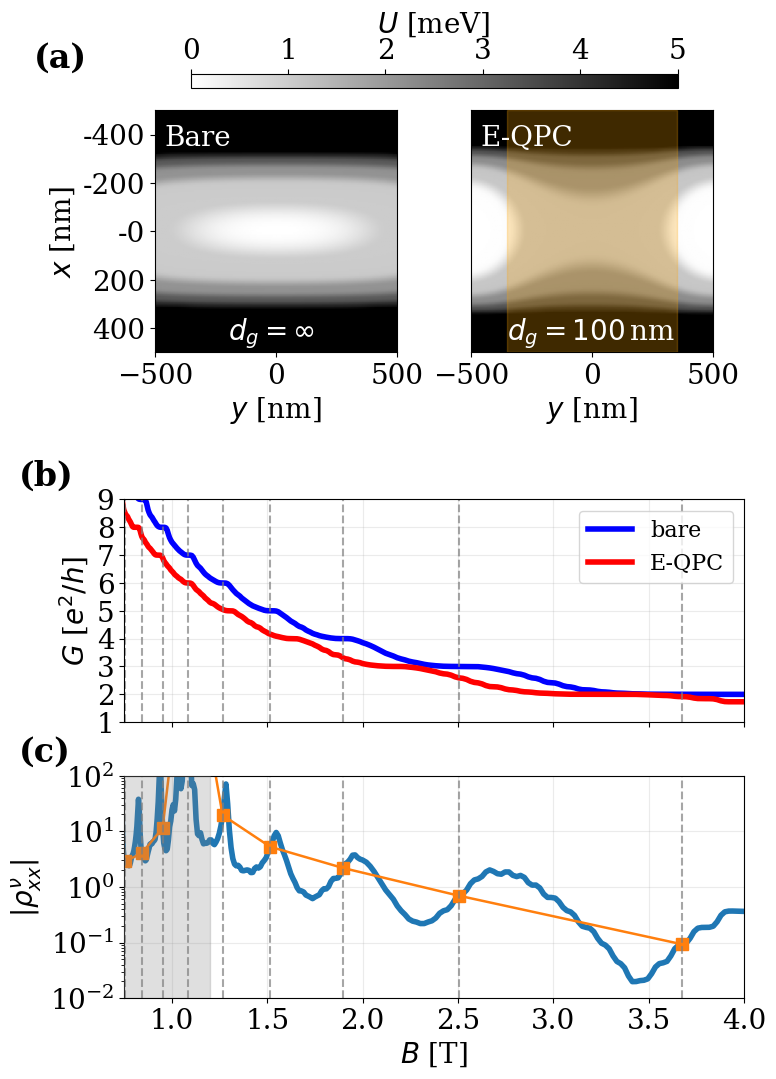

In [45]:
# ============================================================
# Combined figure
# Top: cropped self-consistent potentials for S-QPC and bare
# (a) Conductance comparison
# (b) rho_xx^nu
# ============================================================

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 20,
}

plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']


# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------
fig = plt.figure(figsize=(8, 12))

gs = fig.add_gridspec(
    4, 1,
    height_ratios=[1.25,0.18, 1.0, 1.0],
    hspace=0.28
)

# Double top panel
gs_top = gs[0].subgridspec(1, 2, wspace=0.04)
axU0 = fig.add_subplot(gs_top[0, 0])
axU1 = fig.add_subplot(gs_top[0, 1], sharey=axU0)

# Transport panels
ax1 = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[3], sharex=ax1)


# ============================================================
# Top double panel: cropped potential maps
# ============================================================
# Numerical horizontal coordinate = stored x, cropped to +/-500 nm.
# Numerical vertical coordinate   = stored y.
# Display labels only are swapped: horizontal -> y, vertical -> x.
# The vertical displayed numbers are sign-flipped, so top is negative
# and bottom is positive.

# Left: S-QPC / close top gate
im0 = axU0.imshow(
    U_pot_0_crop,
    extent=[
        x_pot_0_crop[0], x_pot_0_crop[-1],
        y_pot_0[0], y_pot_0[-1]
    ],
    origin='lower',
    aspect='equal',
    cmap='binary',
    vmin=0,
    vmax=5,
)

# Right: bare / effectively distant top gate
im1 = axU1.imshow(
    U_pot_1_crop,
    extent=[
        x_pot_1_crop[0], x_pot_1_crop[-1],
        y_pot_1[0], y_pot_1[-1]
    ],
    origin='lower',
    aspect='equal',
    cmap='binary',
    vmin=0,
    vmax=5,
)
axU1.axvspan(
    -350, 350,
    color="orange",
    alpha=0.25,
    zorder=3
)

# Swap labels only (not numerical coordinates)
axU0.set_xlabel(r"$y$ [nm]")
axU0.set_ylabel(r"$x$ [nm]")
axU1.set_xlabel(r"$y$ [nm]")

# Flip only the displayed signs of the vertical-axis tick labels.
# The data and the axis direction remain unchanged.
yticks = axU0.get_yticks()
yticks = yticks[(yticks >= y_pot_0[0]) & (yticks <= y_pot_0[-1])]
axU0.set_yticks(yticks)
axU0.set_yticklabels([f"{(-t):g}" for t in yticks])

# Right map uses the vertical scale of the left map
axU1.tick_params(axis='y', which='both', left=False, labelleft=False)

# Optional short identifiers inside the maps
axU0.text(
    0.04, 0.94, "Bare",
    transform=axU0.transAxes,
    ha='left', va='top',
    fontsize=20,
    color='white'
)
axU0.text(
    0.3, 0.15, r"$d_g=\infty$",
    transform=axU0.transAxes,
    ha='left', va='top',
    fontsize=20,
    color='white'
)
axU1.text(
    0.04, 0.94, "E-QPC",
    transform=axU1.transAxes,
    ha='left', va='top',
    fontsize=20,
    color='white'
)
axU1.text(
    0.15, 0.15, r"$d_g=100\,$nm",
    transform=axU1.transAxes,
    ha='left', va='top',
    fontsize=20,
    color='white'
)

# Single horizontal colorbar above both potential maps
cbar = fig.colorbar(
    im1,
    ax=[axU0, axU1],
    orientation='horizontal',
    location='top',
    fraction=0.05,
    pad=0.08,
    aspect=35
)
cbar.set_label(r"$U$ [meV]")


# ============================================================
# (a) Conductance
# ============================================================
ax1.plot(
    B_0, G_0_smooth,
    lw=4,
    color='blue',
    label="bare"
)

ax1.plot(
    B_1, G_1_smooth,
    lw=4,
    color='red',
    label="E-QPC"
)

ax1.tick_params(axis="x", which="both", labelbottom=False)
ax1.set_ylabel(r"$G$ [$e^2/h$]")
ax1.set_yticks(np.arange(0, 12, 1))
ax1.set_ylim(1, 9)
ax1.set_xlim(.75, 4)
ax1.grid(alpha=0.25)
ax1.legend(fontsize=16)

# Vertical lines at the bare-curve plateau positions
for Bp in B[plateau_idx]:
    ax1.axvline(
        Bp,
        color="0.5",
        ls="--",
        lw=1.5,
        alpha=0.7
    )


# ============================================================
# (b) rho_xx^nu
# ============================================================
ax2.plot(
    B,
    abs(rhoxxnu),
    ms=4,
    lw=4
)

ax2.plot(
    B[plateau_idx],
    abs(rhoxxnu[plateau_idx]),
    marker="s",
    ms=8,
    lw=1.8
)

ax2.axhline(
    0,
    color="0.5",
    ls="--",
    lw=1
)

ax2.axvspan(
    .75, 1.2,
    color="grey",
    alpha=0.25,
    zorder=3
)

ax2.set_xlabel(r"$B$ [T]")
ax2.set_ylabel(r"$|\rho_{xx}^{\nu}|$")
ax2.set_yscale("log")
ax2.set_ylim(1e-2, 1e2)
ax2.set_xlim(.75, 4)
ax2.grid(alpha=0.25)

# Vertical lines at the bare-curve plateau positions
for Bp in B[plateau_idx]:
    ax2.axvline(
        Bp,
        color="0.5",
        ls="--",
        lw=1.5,
        alpha=0.7
    )

# ============================================================
# Macro-panel labels
# ============================================================

# (a): the two potential maps together
axU0.text(
    -0.5, 1.15, "(a)",
    transform=axU0.transAxes,
    fontsize=24,
    fontweight="bold",
    ha="left",
    va="bottom"
)

# (b): conductance
ax1.text(
    -0.17, 1.03, "(b)",
    transform=ax1.transAxes,
    fontsize=24,
    fontweight="bold",
    ha="left",
    va="bottom"
)

# (c): rho_xx
ax2.text(
    -0.17, 1.03, "(c)",
    transform=ax2.transAxes,
    fontsize=24,
    fontweight="bold",
    ha="left",
    va="bottom"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
plt.savefig(
    "G_rhoxxnu_with_potential.png",
    bbox_inches="tight",
    dpi=300,
)

plt.show()
